In [2]:
!df -h /content
!pip -q install gdown rasterio tqdm pandas numpy matplotlib

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  43% /


In [4]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_ZIP = "/content/drive/MyDrive/thermal-edge-fire.zip"  # change if needed
!unzip -q "$PROJECT_ZIP" -d /content

%cd /content/thermal-edge-fire

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/thermal-edge-fire


In [5]:
import os
from pathlib import Path

DATA_DIR = Path("/content")
AFRICA_ARCHIVE = DATA_DIR / "Africa.zip"
METADATA_ARCHIVE = DATA_DIR / "africa_metadata.zip"
METADATA_DIR = Path("/content/thermal-edge-fire/data/interim/africa_metadata_extracted")

AFRICA_URL = "https://drive.google.com/file/d/1Ng3JwsjJPApshk8lJdGcsNHI52NaEMDX/view"
METADATA_URL = "https://drive.google.com/file/d/1fmJnKLuCMKSa303yw76DIU2clWEU82Na/view"

if not AFRICA_ARCHIVE.exists():
    !gdown --fuzzy "$AFRICA_URL" -O "$AFRICA_ARCHIVE"

if not METADATA_ARCHIVE.exists():
    !gdown --fuzzy "$METADATA_URL" -O "$METADATA_ARCHIVE"

print("Africa archive:", AFRICA_ARCHIVE.stat().st_size / 1024**3, "GB")
print("Metadata archive:", METADATA_ARCHIVE.stat().st_size / 1024**2, "MB")

Downloading...
From (original): https://drive.google.com/uc?id=1Ng3JwsjJPApshk8lJdGcsNHI52NaEMDX
From (redirected): https://drive.google.com/uc?id=1Ng3JwsjJPApshk8lJdGcsNHI52NaEMDX&confirm=t&uuid=9fe8e5a2-2fd4-4f8f-ba0c-ddc79722adc3
To: /content/Africa.zip
100% 31.7G/31.7G [11:46<00:00, 44.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fmJnKLuCMKSa303yw76DIU2clWEU82Na
To: /content/africa_metadata.zip
100% 1.73M/1.73M [00:00<00:00, 108MB/s]
Africa archive: 29.488775125704706 GB
Metadata archive: 1.647684097290039 MB


In [6]:
import zipfile

METADATA_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(METADATA_ARCHIVE) as zf:
    zf.extractall(METADATA_DIR)

print("Metadata scene archives:", len(list(METADATA_DIR.glob("z*.zip"))))

Metadata scene archives: 763


In [11]:
!rm -rf /content/africa_prepared
!mkdir -p /content/africa_prepared/patches
!mkdir -p /content/africa_prepared/masks/algorithmic

!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   78G   36G  69% /


In [13]:
# ================================================================
# STORAGE-SAFE AFRICA SUBSET EXTRACTION
# Extracts 2,000 image patches and only their matching 3 masks.
# No outer_zip object is kept between notebook cells.
# ================================================================

import random
import re
import shutil
import tempfile
import zipfile
from pathlib import Path

from tqdm.auto import tqdm

# Must point to the downloaded 29 GB file.
AFRICA_ARCHIVE = "/content/Africa.zip"

# Start with 3,000. You can later raise this to 3,000 if enough space remains.
MAX_PATCHES = 3000
MAX_PATCHES_PER_SCENE = 8
SEED = 42

PREPARED_ROOT = Path("/content/africa_prepared")
PATCH_DIR = PREPARED_ROOT / "patches"
ALGORITHM_MASK_DIR = PREPARED_ROOT / "masks" / "algorithmic"

PATCH_DIR.mkdir(parents=True, exist_ok=True)
ALGORITHM_MASK_DIR.mkdir(parents=True, exist_ok=True)

# Keep these three independent algorithmic labels for voting.
ALGORITHMS = ("Kumar-Roy", "Murphy", "Schroeder")


def scene_id_from_member(member_name):
    """
    z166052.zip       -> z166052
    z166052_masks.zip -> z166052
    """
    return re.sub(r"(_masks)?\.zip$", "", Path(member_name).name)


def canonical_patch_name(mask_filename):
    """
    LC08_..._Murphy_p00123.tif
    -> LC08_..._p00123.tif
    """
    name = Path(mask_filename).name
    return re.sub(
        r"_(Kumar-Roy|Murphy|Schroeder)_p",
        "_p",
        name,
    )


def open_nested_zip(archive_path, member_name):
    """
    Safely reads one z*.zip member of Africa.zip.

    It does not rely on a global open ZIP object, preventing the
    'ZIP archive already closed' error.
    """
    buffer = tempfile.SpooledTemporaryFile(max_size=256 * 1024 * 1024)

    with zipfile.ZipFile(archive_path, "r") as archive:
        with archive.open(member_name) as source:
            shutil.copyfileobj(source, buffer)

    buffer.seek(0)
    return buffer, zipfile.ZipFile(buffer, "r")


# ------------------------------------------------
# Find all scene image and mask archives.
# ------------------------------------------------
with zipfile.ZipFile(AFRICA_ARCHIVE, "r") as archive:
    all_member_names = archive.namelist()

image_members = [
    name for name in all_member_names
    if re.fullmatch(r"z\d+\.zip", Path(name).name)
]

mask_members = [
    name for name in all_member_names
    if re.fullmatch(r"z\d+_masks\.zip", Path(name).name)
]

print("Image scene archives:", len(image_members))
print("Mask scene archives: ", len(mask_members))


# ------------------------------------------------
# Extract a geographically spread subset of images.
# ------------------------------------------------
rng = random.Random(SEED)
image_members = list(image_members)
rng.shuffle(image_members)

selected_patch_names = set()
selected_scene_ids = set()

for outer_member in tqdm(image_members, desc="Selecting image patches"):
    if len(selected_patch_names) >= MAX_PATCHES:
        break

    scene_id = scene_id_from_member(outer_member)

    try:
        buffer, nested_zip = open_nested_zip(AFRICA_ARCHIVE, outer_member)

        try:
            tif_infos = [
                info for info in nested_zip.infolist()
                if not info.is_dir() and info.filename.lower().endswith(".tif")
            ]

            rng.shuffle(tif_infos)

            # Prevent large scenes dominating the dataset.
            for tif_info in tif_infos[:MAX_PATCHES_PER_SCENE]:
                if len(selected_patch_names) >= MAX_PATCHES:
                    break

                patch_name = Path(tif_info.filename).name
                destination_file = PATCH_DIR / patch_name

                with nested_zip.open(tif_info) as src, open(destination_file, "wb") as dst:
                    shutil.copyfileobj(src, dst)

                selected_patch_names.add(patch_name)
                selected_scene_ids.add(scene_id)

        finally:
            nested_zip.close()
            buffer.close()

    except (zipfile.BadZipFile, OSError) as error:
        print(f"Skipping image archive {outer_member}: {error}")

print(f"\nSelected image patches: {len(selected_patch_names)}")
print(f"Selected scenes: {len(selected_scene_ids)}")


# ------------------------------------------------
# Extract ONLY matching masks for selected patches.
# ------------------------------------------------
mask_member_by_scene = {
    scene_id_from_member(member_name): member_name
    for member_name in mask_members
}

saved_masks = 0

for scene_id in tqdm(sorted(selected_scene_ids), desc="Extracting matching masks"):
    mask_member = mask_member_by_scene.get(scene_id)

    if mask_member is None:
        continue

    try:
        buffer, nested_zip = open_nested_zip(AFRICA_ARCHIVE, mask_member)

        try:
            for mask_info in nested_zip.infolist():
                if mask_info.is_dir() or not mask_info.filename.lower().endswith(".tif"):
                    continue

                mask_name = Path(mask_info.filename).name

                # Retain only the three voters used to make consensus masks.
                if not any(f"_{algorithm}_p" in mask_name for algorithm in ALGORITHMS):
                    continue

                matched_patch_name = canonical_patch_name(mask_name)

                if matched_patch_name not in selected_patch_names:
                    continue

                destination_file = ALGORITHM_MASK_DIR / mask_name

                with nested_zip.open(mask_info) as src, open(destination_file, "wb") as dst:
                    shutil.copyfileobj(src, dst)

                saved_masks += 1

        finally:
            nested_zip.close()
            buffer.close()

    except (zipfile.BadZipFile, OSError) as error:
        print(f"Skipping mask archive {mask_member}: {error}")


print("\n--- Extraction complete ---")
print("Image patches:", len(list(PATCH_DIR.glob("*.tif"))))
print("Algorithmic masks:", saved_masks)

!df -h /content

Image scene archives: 513
Mask scene archives:  513


Selecting image patches:   0%|          | 0/513 [00:00<?, ?it/s]


Selected image patches: 3000
Selected scenes: 506


Extracting matching masks:   0%|          | 0/506 [00:00<?, ?it/s]


--- Extraction complete ---
Image patches: 3000
Algorithmic masks: 6461
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   82G   31G  73% /


In [14]:
import re
import rasterio
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm.auto import tqdm

VOTING_DIR = PREPARED_ROOT / "masks" / "voting_strict"
VOTING_DIR.mkdir(parents=True, exist_ok=True)

ALGORITHMS = ("kumar_roy", "murphy", "schroeder")

def identify_algorithm(stem: str):
    stem_lower = stem.lower()

    if "kumar-roy" in stem_lower or "kumar_roy" in stem_lower:
        return "kumar_roy"
    if "murphy" in stem_lower:
        return "murphy"
    if "schroeder" in stem_lower:
        return "schroeder"

    return None

def image_stem_from_mask(mask_stem: str):
    """
    Convert:
      LC08_..._Murphy_p00543
    into:
      LC08_..._p00543
    """
    return re.sub(
        r"_(Kumar[-_]?Roy|Murphy|Schroeder)_p",
        "_p",
        mask_stem,
        flags=re.IGNORECASE,
    )

image_files = {path.stem: path for path in PATCH_DIR.glob("*.tif")}
masks_by_image = defaultdict(dict)

for mask_file in ALGORITHM_MASK_DIR.glob("*.tif"):
    algorithm = identify_algorithm(mask_file.stem)

    if algorithm is None:
        continue

    image_stem = image_stem_from_mask(mask_file.stem)

    if image_stem in image_files:
        masks_by_image[image_stem][algorithm] = mask_file

records = []

for image_stem, image_file in tqdm(image_files.items(), desc="Creating strict voting masks"):
    source_masks = masks_by_image.get(image_stem, {})

    # Exclude patches with fewer than two independent label sources.
    if len(source_masks) < 2:
        continue

    binary_masks = []
    reference_profile = None

    for algorithm in ALGORITHMS:
        mask_file = source_masks.get(algorithm)

        if mask_file is None:
            continue

        with rasterio.open(mask_file) as src:
            mask = src.read(1)
            binary_masks.append((mask > 0).astype(np.uint8))

            if reference_profile is None:
                reference_profile = src.profile.copy()

    if len(binary_masks) < 2:
        continue

    # Strict consensus: at least two algorithms must agree.
    vote_count = np.sum(binary_masks, axis=0)
    voting_mask = (vote_count >= 2).astype(np.uint8)

    output_mask = VOTING_DIR / f"{image_stem}_voting.tif"

    reference_profile.update(
        driver="GTiff",
        count=1,
        dtype="uint8",
        nodata=0,
        compress="lzw",
    )

    with rasterio.open(output_mask, "w", **reference_profile) as dst:
        dst.write(voting_mask, 1)

    scene_match = re.search(r"LC08_[A-Z0-9]+_(\d{3})(\d{3})_", image_stem)

    records.append(
        {
            "stem": image_stem,
            "image_path": str(image_file),
            "mask_path": str(output_mask),
            "has_mask": True,
            "n_label_algorithms": len(binary_masks),
            "fire_pixels": int(voting_mask.sum()),
            "path": int(scene_match.group(1)) if scene_match else None,
            "row": int(scene_match.group(2)) if scene_match else None,
        }
    )

strict_inventory = pd.DataFrame(records)

STRICT_INVENTORY = PREPARED_ROOT / "training_inventory_strict_voting.csv"
strict_inventory.to_csv(STRICT_INVENTORY, index=False)

print("Strict trainable image/mask pairs:", len(strict_inventory))
print("Zero-fire consensus masks:", int((strict_inventory.fire_pixels == 0).sum()))
display(strict_inventory.n_label_algorithms.value_counts().sort_index())
display(strict_inventory.fire_pixels.describe())

Creating strict voting masks:   0%|          | 0/3000 [00:00<?, ?it/s]

Strict trainable image/mask pairs: 2065
Zero-fire consensus masks: 15


,count
n_label_algorithms,
2,669
3,1396


,fire_pixels
count,2065.000000
mean,8.499758
std,25.063681
min,0.000000
25%,1.000000
50%,2.000000
75%,6.000000
max,442.000000


In [15]:
print("Prepared root:", PREPARED_ROOT)
print("Patches:", len(list(PATCH_DIR.glob('*.tif'))))
print("Algorithmic masks:", len(list(ALGORITHM_MASK_DIR.glob('*.tif'))))
print("Strict voting masks:", len(list(VOTING_DIR.glob('*.tif'))))
print("Strict inventory:", STRICT_INVENTORY)

display(strict_inventory.head())

Prepared root: /content/africa_prepared
Patches: 3000
Algorithmic masks: 6461
Strict voting masks: 2065
Strict inventory: /content/africa_prepared/training_inventory_strict_voting.csv


,stem,image_path,mask_path,has_mask,n_label_algorithms,fire_pixels,path,row
0,LC08_L1TP_166070_20200816_20200816_01_RT_p00424,/content/africa_prepared/patches/LC08_L1TP_166...,/content/africa_prepared/masks/voting_strict/L...,True,3,9,166,70
1,LC08_L1TP_170072_20200812_20200812_01_RT_p00705,/content/africa_prepared/patches/LC08_L1TP_170...,/content/africa_prepared/masks/voting_strict/L...,True,3,6,170,72
2,LC08_L1TP_161074_20200813_20200813_01_RT_p00824,/content/africa_prepared/patches/LC08_L1TP_161...,/content/africa_prepared/masks/voting_strict/L...,True,3,2,161,74
3,LC08_L1TP_173049_20200817_20200817_01_RT_p00554,/content/africa_prepared/patches/LC08_L1TP_173...,/content/africa_prepared/masks/voting_strict/L...,True,3,1,173,49
4,LC08_L1TP_175073_20200815_20200815_01_RT_p00268,/content/africa_prepared/patches/LC08_L1TP_175...,/content/africa_prepared/masks/voting_strict/L...,True,3,2,175,73


In [16]:
FULL_DATA_ROOT = Path("/content/africa_prepared")
STRICT_INVENTORY = FULL_DATA_ROOT / "training_inventory_strict_voting.csv"

In [18]:
from pathlib import Path
import csv, random, re, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, WeightedRandomSampler

# Your prepared 3,000-patch subset.
FULL_DATA_ROOT = Path("/content/africa_prepared")

# Folder where the downloaded project was extracted.
PROJECT_ROOT = Path("/content/thermal-edge-fire")

# Output location for metrics, figures, and checkpoints.
OUTPUT_DIR = PROJECT_ROOT / "reports" / "training_africa_tiny_unet"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert FULL_DATA_ROOT.exists(), f"Missing: {FULL_DATA_ROOT}"
assert (FULL_DATA_ROOT / "patches").exists(), "Missing patches folder."
assert (FULL_DATA_ROOT / "masks" / "voting_strict").exists(), "Run the voting-mask cell first."

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Prepared data:", FULL_DATA_ROOT)
print("Project root:", PROJECT_ROOT)
print("Device:", device)
print("PyTorch:", torch.__version__)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Prepared data: /content/africa_prepared
Project root: /content/thermal-edge-fire
Device: cuda
PyTorch: 2.11.0+cu128
GPU: Tesla T4


In [20]:
import sys
from pathlib import Path

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from fireedge.data.dataset import ActiveFireDataset

STRICT_INVENTORY = FULL_DATA_ROOT / "training_inventory_strict_voting.csv"

df_all = pd.read_csv(STRICT_INVENTORY)

assert len(df_all) > 0, "No strict voting pairs were created."

# CSV values are strings, so convert each one to Path before calling exists().
df_all["image_path"] = df_all["image_path"].astype(str)
df_all["mask_path"] = df_all["mask_path"].astype(str)

assert df_all["image_path"].map(lambda p: Path(p).exists()).all(), \
    "Some image paths are missing."

assert df_all["mask_path"].map(lambda p: Path(p).exists()).all(), \
    "Some voting mask paths are missing."

df_all["path"] = pd.to_numeric(df_all["path"], errors="coerce")
df_all["row"] = pd.to_numeric(df_all["row"], errors="coerce")

print(f"Strict voting training pairs: {len(df_all):,}")
print(f"Fire pixels in all masks: {df_all['fire_pixels'].sum():,}")

display(df_all.head())

Strict voting training pairs: 2,065
Fire pixels in all masks: 17,552


,stem,image_path,mask_path,has_mask,n_label_algorithms,fire_pixels,path,row
0,LC08_L1TP_166070_20200816_20200816_01_RT_p00424,/content/africa_prepared/patches/LC08_L1TP_166...,/content/africa_prepared/masks/voting_strict/L...,True,3,9,166,70
1,LC08_L1TP_170072_20200812_20200812_01_RT_p00705,/content/africa_prepared/patches/LC08_L1TP_170...,/content/africa_prepared/masks/voting_strict/L...,True,3,6,170,72
2,LC08_L1TP_161074_20200813_20200813_01_RT_p00824,/content/africa_prepared/patches/LC08_L1TP_161...,/content/africa_prepared/masks/voting_strict/L...,True,3,2,161,74
3,LC08_L1TP_173049_20200817_20200817_01_RT_p00554,/content/africa_prepared/patches/LC08_L1TP_173...,/content/africa_prepared/masks/voting_strict/L...,True,3,1,173,49
4,LC08_L1TP_175073_20200815_20200815_01_RT_p00268,/content/africa_prepared/patches/LC08_L1TP_175...,/content/africa_prepared/masks/voting_strict/L...,True,3,2,175,73


In [21]:
# ================================================================
# ALL-AFRICA, SCENE-LEVEL TRAIN / VALIDATION / TEST SPLIT
# 70% train, 15% validation, 15% final test
# ================================================================

df = df_all.copy()

# Remove the patch suffix so every patch from the same Landsat scene
# is always placed in the same split.
df["parent_scene"] = df["stem"].str.replace(r"_p\d+$", "", regex=True)

rng = np.random.default_rng(SEED)

all_scenes = df["parent_scene"].drop_duplicates().to_numpy()
rng.shuffle(all_scenes)

assert len(all_scenes) >= 3, "Need at least three different scenes for splitting."

n_scenes = len(all_scenes)
n_test_scenes = max(1, int(round(0.15 * n_scenes)))
n_val_scenes = max(1, int(round(0.15 * n_scenes)))

test_scenes = set(all_scenes[:n_test_scenes])
val_scenes = set(all_scenes[n_test_scenes:n_test_scenes + n_val_scenes])
train_scenes = set(all_scenes[n_test_scenes + n_val_scenes:])

train_df = df[df["parent_scene"].isin(train_scenes)].copy()
val_df = df[df["parent_scene"].isin(val_scenes)].copy()
test_df = df[df["parent_scene"].isin(test_scenes)].copy()

for name, part in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:
    print(
        f"{name:12s} "
        f"patches={len(part):,} | "
        f"scenes={part['parent_scene'].nunique():,} | "
        f"fire pixels={part['fire_pixels'].sum():,}"
    )
    part.to_csv(OUTPUT_DIR / f"{name}_inventory.csv", index=False)

# Safety check: no scene leakage across splits.
assert not (set(train_df["parent_scene"]) & set(val_df["parent_scene"]))
assert not (set(train_df["parent_scene"]) & set(test_df["parent_scene"]))
assert not (set(val_df["parent_scene"]) & set(test_df["parent_scene"]))

train        patches=1,466 | scenes=310 | fire pixels=12,670
validation   patches=293 | scenes=67 | fire pixels=2,152
test         patches=306 | scenes=67 | fire pixels=2,730


In [22]:
def fire_pixels(row):
    return int(read_mask(row.mask_path).sum())
audit_sample = train_df.sample(min(2000, len(train_df)), random_state=SEED).copy()
audit_sample['fire_pixels'] = audit_sample.apply(fire_pixels, axis=1)
display(audit_sample.fire_pixels.describe(percentiles=[.1,.25,.5,.75,.9,.99]).to_frame().T)
print('All-zero masks in audit:', int((audit_sample.fire_pixels == 0).sum()), '/', len(audit_sample))
assert (audit_sample.fire_pixels > 0).any(), 'No positive labels were found; stop and check mask pairing.'
# If all-zero scenes are scarce, add genuine non-fire Landsat patches before claiming a false-alarm rate.

,count,mean,std,min,10%,25%,50%,75%,90%,99%,max
fire_pixels,1466.0,8.642565,24.574116,0.0,1.0,1.0,2.0,6.0,17.5,110.7,350.0


All-zero masks in audit: 8 / 1466


In [24]:
# ================================================================
# DATA LOADERS + TINY U-NET MODEL
# ================================================================

BATCH_SIZE = 8 if device.type == "cuda" else 2
NUM_WORKERS = 2 if device.type == "cuda" else 0

train_ds = ActiveFireDataset(
    train_df,
    channels=(8,),           # Landsat B10 thermal band
    norm_method="fixed",
    augment=True,
    random_seed=SEED,
)

val_ds = ActiveFireDataset(
    val_df,
    channels=(8,),
    norm_method="fixed",
    augment=False,
)

test_ds = ActiveFireDataset(
    test_df,
    channels=(8,),
    norm_method="fixed",
    augment=False,
)

# All-Africa training: shuffle normally.
# Do not use the old North-Mediterranean weighted sampler.
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

# Verify one loaded batch before training.
x, y = next(iter(train_loader))

print("Image batch:", x.shape, x.dtype)
print("Image range:", (x.min().item(), x.max().item()))
print("Mask values:", y.unique())
print("Mask batch:", y.shape)


class ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class TinyUNet(nn.Module):
    """
    Lightweight single-channel U-Net for binary fire segmentation.
    Input:  [B, 1, 256, 256]
    Output: [B, 1, 256, 256] logits
    """
    def __init__(self, base=8):
        super().__init__()

        self.e1 = ConvBlock(1, base)
        self.e2 = ConvBlock(base, base * 2)
        self.e3 = ConvBlock(base * 2, base * 4)

        self.pool = nn.MaxPool2d(2)
        self.mid = ConvBlock(base * 4, base * 8)

        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, 2, 2)
        self.d3 = ConvBlock(base * 8, base * 4)

        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, 2)
        self.d2 = ConvBlock(base * 4, base * 2)

        self.u1 = nn.ConvTranspose2d(base * 2, base, 2, 2)
        self.d1 = ConvBlock(base * 2, base)

        self.out = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))

        middle = self.mid(self.pool(e3))

        d3 = self.d3(torch.cat([self.u3(middle), e3], dim=1))
        d2 = self.d2(torch.cat([self.u2(d3), e2], dim=1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], dim=1))

        return self.out(d1)


model = TinyUNet(base=8).to(device)

print("Model parameters:", f"{sum(p.numel() for p in model.parameters()):,}")

# Confirm model output has the expected shape.
with torch.no_grad():
    output = model(x.to(device))

print("Model output:", output.shape)

Image batch: torch.Size([8, 1, 256, 256]) torch.float32
Image range: (0.0, 0.2512580454349518)
Mask values: tensor([0., 1.])
Mask batch: torch.Size([8, 1, 256, 256])
Model parameters: 121,033
Model output: torch.Size([8, 1, 256, 256])


In [25]:
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, gamma=0.75, eps=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.eps = eps

    def forward(self, logits, targets):
        probabilities = torch.sigmoid(logits)
        dims = (1, 2, 3)

        true_positive = (probabilities * targets).sum(dims)
        false_positive = (probabilities * (1 - targets)).sum(dims)
        false_negative = ((1 - probabilities) * targets).sum(dims)

        tversky = (
            (true_positive + self.eps)
            / (
                true_positive
                + self.alpha * false_positive
                + self.beta * false_negative
                + self.eps
            )
        )

        return ((1 - tversky) ** self.gamma).mean()


# Fire pixels are extremely rare, so upweight them in BCE.
positive_weight = torch.tensor([25.0], device=device)

bce = nn.BCEWithLogitsLoss(pos_weight=positive_weight)
focal_tversky = FocalTverskyLoss(alpha=0.3, beta=0.7, gamma=0.75)

def loss_fn(logits, targets):
    return 0.3 * bce(logits, targets) + 0.7 * focal_tversky(logits, targets)


@torch.no_grad()
def evaluate(loader, threshold=0.20):
    model.eval()

    true_positive = 0
    false_positive = 0
    false_negative = 0
    losses = []

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        losses.append(loss_fn(logits, masks).item())

        predictions = torch.sigmoid(logits) >= threshold
        targets = masks.bool()

        true_positive += (predictions & targets).sum().item()
        false_positive += (predictions & ~targets).sum().item()
        false_negative += (~predictions & targets).sum().item()

    recall = true_positive / (true_positive + false_negative + 1e-9)
    precision = true_positive / (true_positive + false_positive + 1e-9)
    iou = true_positive / (true_positive + false_positive + false_negative + 1e-9)
    dice = 2 * true_positive / (
        2 * true_positive + false_positive + false_negative + 1e-9
    )

    return {
        "loss": float(np.mean(losses)),
        "recall": recall,
        "precision": precision,
        "iou": iou,
        "dice": dice,
        "tp": true_positive,
        "fp": false_positive,
        "fn": false_negative,
    }


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

EPOCHS = 30
PATIENCE = 6

history = []
best_dice = -1.0
stale_epochs = 0

In [26]:
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for images, masks in train_loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = loss_fn(logits, masks)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_losses.append(loss.item())

    metrics = evaluate(val_loader, threshold=0.20)

    row = {
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        **metrics,
    }
    history.append(row)

    print(
        f"{epoch:02d} "
        f"train={row['train_loss']:.4f} "
        f"val_loss={row['loss']:.4f} "
        f"recall={row['recall']:.3f} "
        f"precision={row['precision']:.3f} "
        f"dice={row['dice']:.3f} "
        f"iou={row['iou']:.3f}"
    )

    if metrics["dice"] > best_dice:
        best_dice = metrics["dice"]
        stale_epochs = 0

        torch.save(
            {
                "model_state": model.state_dict(),
                "epoch": epoch,
                "validation": metrics,
                "threshold": 0.50,
            },
            OUTPUT_DIR / "best_tiny_unet.pt",
        )
    else:
        stale_epochs += 1

        if stale_epochs >= PATIENCE:
            print("Early stopping.")
            break

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "history.csv", index=False)

display(history_df.tail())

01 train=0.8188 val_loss=0.7783 recall=0.937 precision=0.000 dice=0.000 iou=0.000
02 train=0.7554 val_loss=0.7377 recall=0.216 precision=0.005 dice=0.010 iou=0.005
03 train=0.7274 val_loss=0.7211 recall=0.243 precision=0.098 dice=0.140 iou=0.075
04 train=0.7148 val_loss=0.7103 recall=0.351 precision=0.065 dice=0.110 iou=0.058
05 train=0.7081 val_loss=0.7083 recall=0.507 precision=0.004 dice=0.008 iou=0.004
06 train=0.7031 val_loss=0.7001 recall=0.436 precision=0.096 dice=0.158 iou=0.086
07 train=0.6981 val_loss=0.6915 recall=0.511 precision=0.070 dice=0.124 iou=0.066
08 train=0.6929 val_loss=0.6874 recall=0.520 precision=0.044 dice=0.081 iou=0.042
09 train=0.6879 val_loss=0.6879 recall=0.276 precision=0.222 dice=0.246 iou=0.140
10 train=0.6778 val_loss=0.6734 recall=0.392 precision=0.220 dice=0.282 iou=0.164
11 train=0.6686 val_loss=0.6745 recall=0.286 precision=0.157 dice=0.203 iou=0.113
12 train=0.6630 val_loss=0.6593 recall=0.428 precision=0.200 dice=0.273 iou=0.158
13 train=0.6618 

,epoch,train_loss,loss,recall,precision,iou,dice,tp,fp,fn
25,26,0.649711,0.659140,0.398234,0.344315,0.226480,0.369317,857,1632,1295
26,27,0.647892,0.651214,0.381506,0.177667,0.137937,0.242433,821,3800,1331
27,28,0.652475,0.660598,0.386152,0.325245,0.214396,0.353091,831,1724,1321
28,29,0.653655,0.654916,0.405204,0.338772,0.226258,0.369022,872,1702,1280
29,30,0.651177,0.651539,0.409387,0.247611,0.182439,0.308581,881,2677,1271


In [28]:
checkpoint = torch.load(
    OUTPUT_DIR / "best_tiny_unet.pt",
    map_location=device,
    weights_only=False,
)

model.load_state_dict(checkpoint["model_state"])

threshold_grid = np.arange(0.05, 0.51, 0.05)

threshold_results = pd.DataFrame([
    {
        "threshold": float(threshold),
        **evaluate(val_loader, threshold=float(threshold)),
    }
    for threshold in threshold_grid
])

# Choose the best Dice threshold among thresholds retaining at least
# 95% of the best validation recall.
eligible = threshold_results[
    threshold_results["recall"]
    >= 0.95 * threshold_results["recall"].max()
]

chosen = threshold_results.sort_values(
    ["dice", "precision"],
    ascending=False,
).iloc[0]

chosen_threshold = float(chosen["threshold"])
print("Balanced chosen threshold:", chosen_threshold)

print("Chosen threshold:", chosen_threshold)
display(threshold_results)

test_metrics = evaluate(test_loader, threshold=chosen_threshold)

pd.DataFrame([test_metrics]).to_csv(
    OUTPUT_DIR / "heldout_test_metrics.csv",
    index=False,
)

print("HELD-OUT ALL-AFRICA TEST METRICS")
print(test_metrics)

assert test_metrics["tp"] + test_metrics["fn"] > 0, (
    "Test set has no labelled fire pixels; report this limitation."
)

Balanced chosen threshold: 0.5
Chosen threshold: 0.5


,threshold,loss,recall,precision,iou,dice,tp,fp,fn
0,0.05,0.65914,0.424257,0.295661,0.211001,0.348473,913,2175,1239
1,0.10,0.65914,0.411245,0.319149,0.219059,0.359391,885,1888,1267
2,0.15,0.65914,0.401952,0.332309,0.222365,0.363828,865,1738,1287
3,0.20,0.65914,0.398234,0.344315,0.226480,0.369317,857,1632,1295
4,0.25,0.65914,0.392193,0.352254,0.227862,0.371152,844,1552,1308
5,0.30,0.65914,0.390799,0.363283,0.231936,0.376539,841,1474,1311
6,0.35,0.65914,0.388941,0.371011,0.234388,0.379764,837,1419,1315
7,0.40,0.65914,0.385688,0.374718,0.234662,0.380124,830,1385,1322
8,0.45,0.65914,0.384758,0.380690,0.236639,0.382713,828,1347,1324
9,0.50,0.65914,0.383364,0.386961,0.238508,0.385154,825,1307,1327


HELD-OUT ALL-AFRICA TEST METRICS
{'loss': 0.6447056761154761, 'recall': 0.440293040292879, 'precision': 0.3337961677310931, 'iou': 0.23435367518030134, 'dice': 0.3797188437844922, 'tp': 1202, 'fp': 2399, 'fn': 1528}


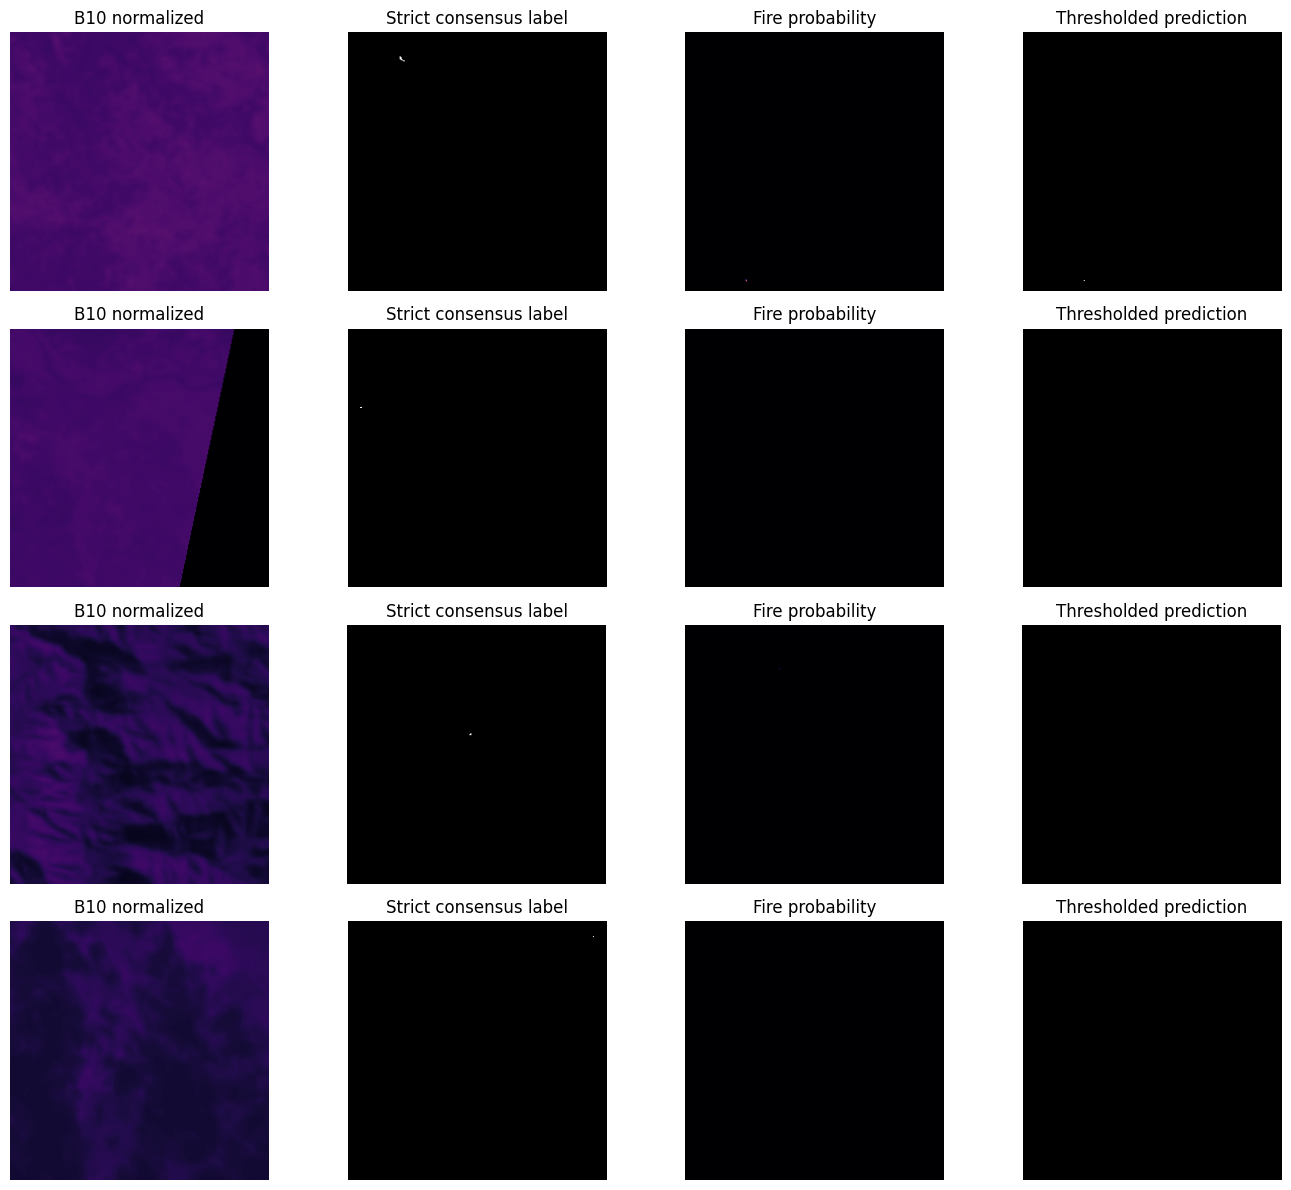

Saved: /content/thermal-edge-fire/reports/training_africa_tiny_unet/heldout_test_predictions.png


In [29]:
model.eval()

images, masks = next(iter(test_loader))
images_on_device = images.to(device)

with torch.no_grad():
    probabilities = torch.sigmoid(model(images_on_device)).cpu()

n = min(4, len(images))

fig, axes = plt.subplots(n, 4, figsize=(14, 3 * n), squeeze=False)

for i in range(n):
    axes[i, 0].imshow(images[i, 0], cmap="inferno", vmin=0, vmax=1)
    axes[i, 0].set_title("B10 normalized")

    axes[i, 1].imshow(masks[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[i, 1].set_title("Strict consensus label")

    axes[i, 2].imshow(probabilities[i, 0], cmap="magma", vmin=0, vmax=1)
    axes[i, 2].set_title("Fire probability")

    axes[i, 3].imshow(
        probabilities[i, 0] >= chosen_threshold,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[i, 3].set_title("Thresholded prediction")

    for ax in axes[i]:
        ax.axis("off")

plt.tight_layout()

figure_path = OUTPUT_DIR / "heldout_test_predictions.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)